# Notebook 3 — Tract-Level CV Choropleth

A first map view of reliability: tract-level **CV** for median household income. Darker/higher CV = noisier estimate. Prototype for the dashboard's reliability-tier map.

**Reliability benchmark used here:** the Census Bureau's ACS quality standard for sampling error says the coefficient of variation for key estimates should be 30% or less for the majority of those key estimates. We use `CV <= 0.30` as a sourced benchmark, not as a universal truth label for every individual estimate. Source: Census Bureau, *Quality Standards Metrics Definitions*.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'JL_Analysis':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'analysis' / 'JL_Analysis'
sys.path.insert(0, str(NOTEBOOK_DIR))

from helpers import compute_cv, estimate_moe_cols, load_acs, load_geo

VAR = 'B19013_001'
est_col, moe_col = estimate_moe_cols(VAR)

In [2]:
acs = load_acs('tract')
geo = load_geo('tract')

acs['cv_income'] = compute_cv(acs[est_col], acs[moe_col], var_code=VAR)
map_df = geo.merge(
    acs[['STATE', 'COUNTY', 'TRACT', 'NAME', 'cv_income', est_col, moe_col]],
    on=['STATE', 'COUNTY', 'TRACT'],
    how='left',
)

valid = map_df['cv_income'].notna()
print(f'Tracts with valid income CV: {valid.sum():,} / {len(map_df):,}')
print(map_df.loc[valid, 'cv_income'].describe().round(3))

Tracts with valid income CV: 2,109 / 2,181
count    2109.000
mean        0.144
std         0.081
min         0.005
25%         0.088
50%         0.128
75%         0.179
max         0.566
Name: cv_income, dtype: float64


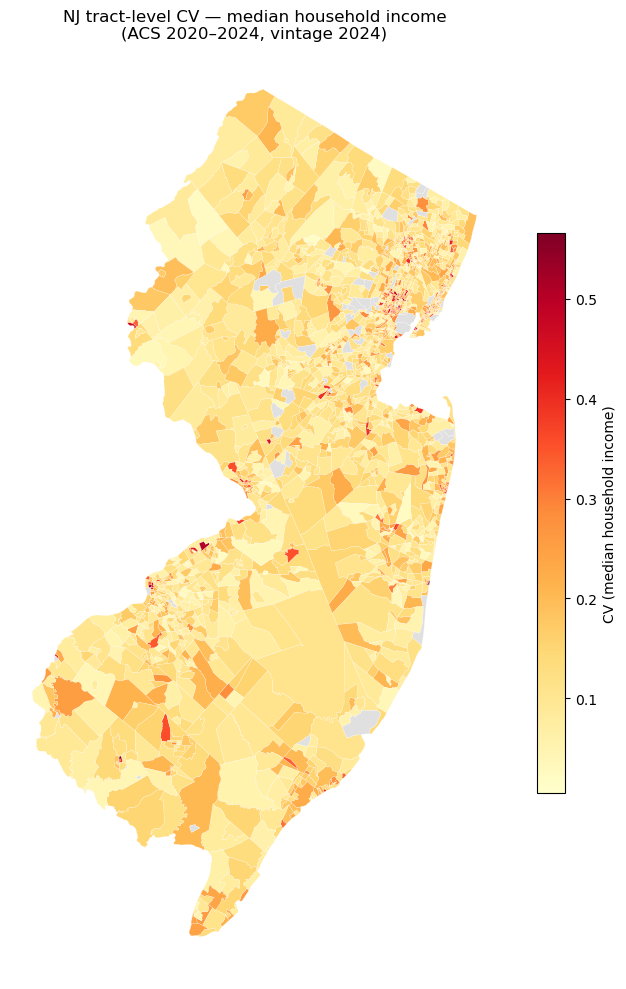

In [3]:
# Census Bureau ACS quality benchmark: CV for key estimates should be 30% or less.
# Source: Quality Standards Metrics Definitions, ACS sampling error metric.
# This is a benchmark for context, not a universal per-estimate truth label.
bins = [0, 0.30, np.inf]
labels = ['CV <= 0.30 (meets Census ACS benchmark)', 'CV > 0.30 (above benchmark)']
colors = ['#2166ac', '#d6604d']

map_df['reliability_tier'] = pd.cut(map_df['cv_income'], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(8, 10))
map_df.plot(
    column='cv_income',
    cmap='YlOrRd',
    linewidth=0.15,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'CV (median household income)', 'shrink': 0.6},
    missing_kwds={'color': '#e0e0e0', 'label': 'No valid CV'},
    ax=ax,
)
ax.set_title('NJ tract-level CV — median household income\n(ACS 2020–2024, vintage 2024)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

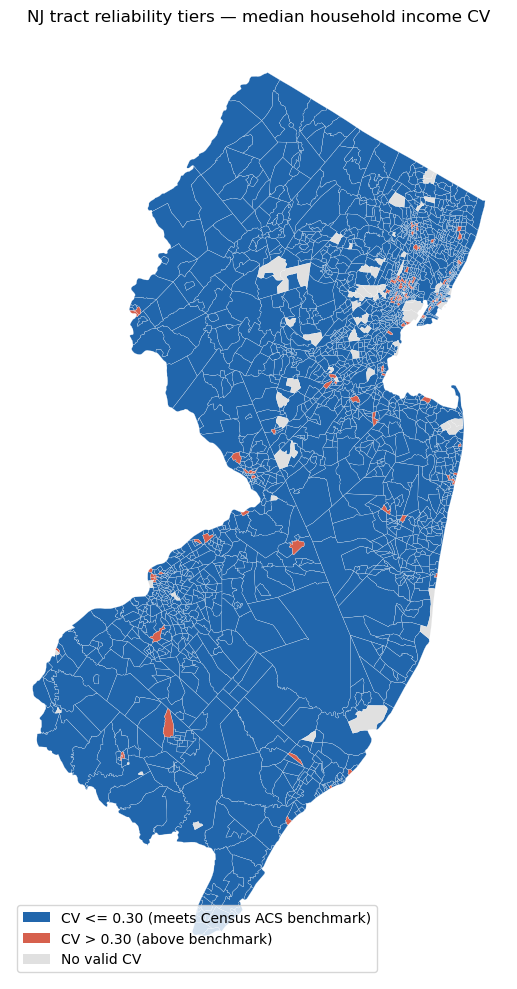

In [4]:
fig, ax = plt.subplots(figsize=(8, 10))
for label, color in zip(labels, colors):
    subset = map_df[map_df['reliability_tier'] == label]
    if len(subset):
        subset.plot(ax=ax, color=color, linewidth=0.15, edgecolor='white')
map_df[map_df['cv_income'].isna()].plot(ax=ax, color='#e0e0e0', linewidth=0.1, edgecolor='white')
ax.set_title('NJ tract reliability tiers — median household income CV')
ax.set_axis_off()
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in zip(labels, colors)] + [Patch(facecolor='#e0e0e0', label='No valid CV')], loc='lower left')
plt.tight_layout()
plt.show()